# Misc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import rankdata
from datetime import datetime

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.join(notebook_dir, 'Result', 'Benchmark')  
os.chdir(project_dir)
os.getcwd()

'd:\\Jacky\\MATLAB\\OptimalPlacement\\Result\\Benchmark'

In [2]:
def R_method(Pareto_font, rank_obj):
    Pareto_font = np.asarray(Pareto_font, dtype=float)
    rank_obj = np.asarray(rank_obj, dtype=float)

    numSol, numVar = Pareto_font.shape

    # Rank variables (MATLAB tiedrank)
    rankVar = np.zeros_like(Pareto_font)
    for j in range(numVar):
        rankVar[:, j] = rankdata(Pareto_font[:, j], method="average")

    # Variable weight set
    numRank = np.arange(1, numSol + 1)
    denom_sol = sum(1 / np.sum(1 / numRank[:j]) for j in range(1, numSol + 1))
    weightsVar_set = np.array([
        (1 / np.sum(1 / numRank[:j])) / denom_sol
        for j in range(1, numSol + 1)
    ])

    # Objective weight set
    numRankObj = np.arange(1, numVar + 1)
    denom_obj = sum(1 / np.sum(1 / numRankObj[:j]) for j in range(1, numVar + 1))
    weightsObj_set = np.array([
        (1 / np.sum(1 / numRankObj[:j])) / denom_obj
        for j in range(1, numVar + 1)
    ])

    # Assign variable weights
    weightsVar = np.zeros_like(Pareto_font)
    for i in range(numSol):
        for j in range(numVar):
            weightsVar[i, j] = weightsVar_set[int(rankVar[i, j]) - 1]

    # Assign objective weights (MATLAB bug preserved)
    weightsObj = np.zeros(numVar)
    for j in range(numVar):
        if not rank_obj[j].is_integer():
            weightsObj[j] = weightsObj_set[0] + weightsObj_set[1]
        else:
            weightsObj[j] = weightsObj_set[int(rank_obj[j]) - 1]

    # Composite score
    composite_score = weightsVar @ weightsObj

    # FINAL RANK — NO INVERSION
    finalRank = rankdata(composite_score, method="average")

    sorted_idx = np.argsort(finalRank)[::-1]
    top5_loc = sorted_idx[:5]

    return top5_loc, finalRank, composite_score


# Raw data processing

In [3]:
# Aggregate results from all PCs
pos_all = []
obj_all = []
cwd = os.getcwd()
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        pos = pd.read_excel(file_path, sheet_name="Sheet1", header=None).to_numpy()
        obj = pd.read_excel(file_path, sheet_name="Sheet2", header=None).to_numpy()
        assert pos.shape[0] == obj.shape[0], f"Position and Objective rows do not match in file: {file}!"
        pos_all.append(pos)
        obj_all.append(obj)
    

Folder: 1 (4 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 2.xlsx', 'benchmark result 3.xlsx', 'benchmark result middle.xlsx']
Folder: 2 (15 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 10.xlsx', 'benchmark result 11.xlsx', 'benchmark result 12.xlsx', 'benchmark result 13.xlsx', 'benchmark result 2.xlsx', 'benchmark result 3.xlsx', 'benchmark result 4.xlsx', 'benchmark result 5.xlsx', 'benchmark result 6.xlsx', 'benchmark result 7.xlsx', 'benchmark result 8.xlsx', 'benchmark result 9.xlsx', 'benchmark result middle.xlsx', 'benchmark result.xlsx']
Folder: 3 (33 files)
Files: ['benchmark result 1.xlsx', 'benchmark result 10.xlsx', 'benchmark result 11.xlsx', 'benchmark result 12.xlsx', 'benchmark result 13.xlsx', 'benchmark result 14.xlsx', 'benchmark result 15.xlsx', 'benchmark result 16.xlsx', 'benchmark result 17.xlsx', 'benchmark result 18.xlsx', 'benchmark result 19.xlsx', 'benchmark result 2.xlsx', 'benchmark result 20.xlsx', 'benchmark result 21.xlsx',

In [4]:
pos_all = np.vstack(pos_all)
obj_all = np.vstack(obj_all)

mask = obj_all[:,0] != 100000
obj = obj_all[mask]
position = pos_all[mask]

np.savez('benchmark_all.npz', pos_all=position, obj_all=obj)

pos_all.shape, obj_all.shape, position.shape, obj.shape

((1056046, 9), (1056046, 3), (1056040, 9), (1056040, 3))

# Ranking Pareto font and search space

In [4]:
# SANITY CHECK R-Method
# =============================
Pareto_font = np.array([
    [1, 10, 100],
    [2, 20,  90],
    [3, 30,  80],
    [4, 40,  70],
    [6, 50,  60],
    [5, 50,  60]
])

rank_obj = np.array([1, 2, 3])

top5, final_rank, score = R_method(Pareto_font, rank_obj)

print("\n--- PYTHON RESULTS ---")
print("Top 5 locations (0-based):", top5)
print("Top 5 locations (MATLAB style):", top5 + 1)
print("Final Rank:", final_rank)
print("Composite Score (Top 5):", score)



--- PYTHON RESULTS ---
Top 5 locations (0-based): [0 1 5 4 2]
Top 5 locations (MATLAB style): [1 2 6 5 3]
Final Rank: [6. 5. 2. 1. 3. 4.]
Composite Score (Top 5): [0.24138201 0.17247903 0.14959838 0.14022208 0.15913963 0.16294605]


In [15]:
data = np.load('benchmark_all.npz')
pos_all = data['pos_all']
obj_all = data['obj_all']

pos_all.shape, obj_all.shape

((1056040, 9), (1056040, 3))

In [6]:
# x = obj_all[:, 0] * 1e3        # Power Loss
# y = obj_all[:, 1] / 1e5        # CES Investment
# z = obj_all[:, 2]
# fontttt = 10

# fig = plt.figure(constrained_layout=True)
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x, y, z, c=pos_all[:,1], cmap='viridis', alpha=0.7)
# ax.set_xlabel(r'Power Loss ($\times 10^{-3}$ kW)', fontsize=fontttt)
# ax.set_ylabel(r'CES Investment ($\times 10^{5}$ RM)', fontsize=fontttt)
# ax.set_zlabel('Average Cost of Prosumer (RM)', fontsize=fontttt)

# # Set camera angle
# ax.view_init(elev=30, azim=30)    # elev = vertical angle, azim = rotation (degrees)
# ax.dist = 10                      # camera distance (optional)

# # ax.set_title('Pareto Front in Objective Space', fontsize=14)
# ax.set_box_aspect(aspect=None, zoom=0.85)
# plt.savefig(f"benchmark sol search space.png", format = "png", bbox_inches='tight', dpi = 300)
# plt.show()

In [ ]:
n_old = obj_all.shape[0]   # number of rows BEFORE append

obj_all = np.vstack([
    obj_all,
    [5.56, 682937.76, 71.08],
    [5.35, 879673.67, 71.24],
    [5.12, 559160.47, 71.69]
])

pos_all = np.vstack([
    pos_all,
    [4, 2, 25, 33, 19, 108.78, 81, 223.37, 269.79],
    [3, 20, 33, 22, 0, 309, 261.67, 309, 0],
    [2, 19, 33, 0, 0, 283.52, 275.64, 0, 0]
])

new_indices = np.arange(n_old, n_old + 3)

rank_obj = np.array([1, 2.5, 2.5])

top5, final_rank, score = R_method(obj_all, rank_obj)

sorted_indices = np.argsort(final_rank)[::-1]

# Apply the sorted indices to obj_all and pos_all
sorted_obj_all = obj_all[sorted_indices]
sorted_pos_all = pos_all[sorted_indices]
sorted_score = score[sorted_indices]

# Save the sorted arrays to a .npz file
np.savez('benchmark_ranked_MOO.npz', obj_all=sorted_obj_all, pos_all=sorted_pos_all, score=sorted_score, final_rank=final_rank)

# Print confirmation
print("Top 5 locations (0-based):", top5)
print("Top 5 locations (MATLAB style):", top5 + 1)
print("Composite Score (Top 5):", sorted_score[:5])

KeyboardInterrupt: 

Top 5 locations (0-based): [427420 400062 327476 327596 327716] <br>
Top 5 locations (MATLAB style): [427421 400063 327477 327597 327717] <br>
Composite Score (Top 5): [1.06171759e-05 7.48938372e-06 7.45160750e-06 7.43821614e-06 7.43267392e-06]

In [34]:
new_ranks = {}

for idx in new_indices:
    rank_position = np.where(sorted_indices == idx)[0][0] + 1  # 1-based rank
    new_ranks[idx] = rank_position
    
for i, idx in enumerate(new_indices):
    print(f"New solution {i+1}:")
    print(f"  Objectives = {obj_all[idx]}")
    print(f"  Composite score = {sorted_score[new_ranks[idx]-1]}")
    print(f"  Rank = {new_ranks[idx]} / {len(sorted_score)}\n")

New solution 1:
  Objectives = [5.5600000e+00 6.8293776e+05 7.1080000e+01]
  Composite score = 2.3275694098997343e-06
  Rank = 2855 / 1056043

New solution 2:
  Objectives = [5.3500000e+00 8.7967367e+05 7.1240000e+01]
  Composite score = 2.110829403663431e-06
  Rank = 15536 / 1056043

New solution 3:
  Objectives = [5.1200000e+00 5.5916047e+05 7.1690000e+01]
  Composite score = 1.8865918700520053e-06
  Rank = 232893 / 1056043



In [29]:
np.where(np.argsort(final_rank)[::-1] == 1056042)

(array([232892]),)

In [31]:
# Load and check the saved file (for verification)
data = np.load('benchmark_ranked_MOO.npz')
sorted_pos_all = data['pos_all']
sorted_obj_all_sorted = data['obj_all']
sorted_score = data['score']
final_rank = data['final_rank']

# Computational time

In [3]:
# Aggregate times from all PCs (benchmark processing)
from datetime import datetime, timedelta
durations = []
runtime = {}
cwd = os.getcwd()
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    if folder == 'opt_result':
        continue
    times = []
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    # print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        time = datetime.fromtimestamp(os.path.getmtime(file_path)) if datetime.fromtimestamp(os.path.getmtime(file_path)).month != 12 else datetime(2025, 8, 18, 14, 40, 0)
        times.append(time)
    times.sort()
    # print(f"Modification times (sorted): {times}")
    durations = [(times[i+1] - times[i]) for i in range(len(times)-1)] if durations else [(times[i+1] - times[i]) for i in range(len(times)-1)]
    # for i, d in enumerate(durations):
    #     print(f"Runtime {i+1} → {i+2}: {d}")
    runtime[folder] = sum(durations, start=durations[0]*0)
    print(f"Total runtime for folder {folder}: {sum(durations, start=durations[0]*0)}\n")

grand_total = sum(runtime.values(), start=timedelta(0))
print("Total runtimes:" , grand_total)

total_days_benchmark = grand_total.total_seconds() / (24 * 3600)
total_hours_benchmark = grand_total.total_seconds() / 3600

print(f"Grand total runtime ≈ {total_days_benchmark:.1f} days")
print(f"Grand total runtime ≈ {total_hours_benchmark:.1f} hours")

Folder: 1 (4 files)
Total runtime for folder 1: 14 days, 4:35:18

Folder: 2 (15 files)
Total runtime for folder 2: 40 days, 3:38:12

Folder: 3 (33 files)
Total runtime for folder 3: 180 days, 9:26:34.568640

Total runtimes: 234 days, 17:40:04.568640
Grand total runtime ≈ 234.7 days
Grand total runtime ≈ 5633.7 hours


In [5]:
durations

[datetime.timedelta(days=1, seconds=67677, microseconds=412613),
 datetime.timedelta(days=4, seconds=83385, microseconds=743408),
 datetime.timedelta(seconds=90, microseconds=334623),
 datetime.timedelta(seconds=49346, microseconds=361217),
 datetime.timedelta(days=4, seconds=59826, microseconds=394673),
 datetime.timedelta(days=5, seconds=38863, microseconds=904073),
 datetime.timedelta(seconds=16022, microseconds=160281),
 datetime.timedelta(days=3, seconds=1707, microseconds=693304),
 datetime.timedelta(days=16, seconds=69750, microseconds=905695),
 datetime.timedelta(days=1, seconds=73551, microseconds=867995),
 datetime.timedelta(days=23, seconds=2734, microseconds=187547),
 datetime.timedelta(days=14, seconds=30478, microseconds=617447),
 datetime.timedelta(days=2, seconds=83859, microseconds=182924),
 datetime.timedelta(days=1, seconds=4219, microseconds=36932),
 datetime.timedelta(days=1, seconds=35225, microseconds=142347),
 datetime.timedelta(days=11, seconds=35968, microseco

In [20]:
# Aggregate times from all PCs (MOOs processing)
from datetime import datetime
durations = []
moo_rows = []
moo_rows.append({
        "Method": 'Exhaustive Search',
        "Runtime (hours)": total_hours_benchmark,
        "Runtime (minutes)": total_hours_benchmark * 60,
        "Speed-up vs Benchmark (×)": '-'
    })

cwd = r"D:\Jacky\MATLAB\OptimalPlacement\Result\Data\Computational time"
folders = [d for d in os.listdir(cwd) if os.path.isdir(os.path.join(cwd, d))]
for folder in folders:
    times = []
    folder_path = os.path.join(cwd, folder)
    files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Folder: {folder} ({len(files)} files)")
    # print(f"Files: {files}")
    for file in files:
        file_path = os.path.join(folder_path, file)
        time = datetime.fromtimestamp(os.path.getmtime(file_path)) if datetime.fromtimestamp(os.path.getmtime(file_path)).month != 12 else datetime(2025, 8, 18, 14, 40, 0)
        times.append(time)
    times.sort()
    # print(f"Modification times (sorted): {times}")
    durations = [(times[i+1] - times[i]) for i in range(len(times)-1)] if durations else [(times[i+1] - times[i]) for i in range(len(times)-1)]
    # for i, d in enumerate(durations):
    #     print(f"Runtime {i+1} → {i+2}: {d}")
    # runtime += sum(durations, start=durations[0]*0)
    print(f"Total runtime for folder {folder}: {sum(durations, start=durations[0]*0)}")
    grand_total = sum(durations, start=durations[0]*0)
    total_days = grand_total.total_seconds() / (24 * 3600)
    total_hours = grand_total.total_seconds() / 3600

    print(f"Grand total runtime for folder {folder} ≈ {total_days:.1f} days")
    print(f"Grand total runtime for folder {folder} ≈ {total_hours:.1f} hours\n")
    print(f"Acceleration factor ≈ {total_hours_benchmark / total_hours:.1f}x\n")

    moo_rows.append({
        "Method": folder,
        "Runtime (hours)": total_hours,
        "Runtime (minutes)": total_hours * 60,
        "Speed-up vs Benchmark (×)": total_hours_benchmark / total_hours
    })

moo_rows[1], moo_rows[2], moo_rows[3] = moo_rows[3], moo_rows[1], moo_rows[2]
moo_df = pd.DataFrame(moo_rows)
moo_df


Folder: MOLA (10 files)
Total runtime for folder MOLA: 1 day, 1:04:21.882239
Grand total runtime for folder MOLA ≈ 1.0 days
Grand total runtime for folder MOLA ≈ 25.1 hours

Acceleration factor ≈ 224.7x

Folder: MOMSA (10 files)
Total runtime for folder MOMSA: 21:47:45.792981
Grand total runtime for folder MOMSA ≈ 0.9 days
Grand total runtime for folder MOMSA ≈ 21.8 hours

Acceleration factor ≈ 258.5x

Folder: MOPSO (10 files)
Total runtime for folder MOPSO: 13:46:21.289744
Grand total runtime for folder MOPSO ≈ 0.6 days
Grand total runtime for folder MOPSO ≈ 13.8 hours

Acceleration factor ≈ 409.0x



,Method,Runtime (hours),Runtime (minutes),Speed-up vs Benchmark (×)
0,Exhaustive Search,5633.667936,338020.076144,-
1,MOPSO,13.772580,826.354829,409.049556
2,MOLA,25.072745,1504.364704,224.692905
3,MOMSA,21.796054,1307.763216,258.471925


In [ ]:
output_file = "Runtime_per_Folder.xlsx"
moo_df.to_excel(output_file, index=False)

# P2P operation visualization

In [3]:
os.chdir('..')
os.getcwd()

'd:\\Jacky\\MATLAB\\OptimalPlacement\\Result'

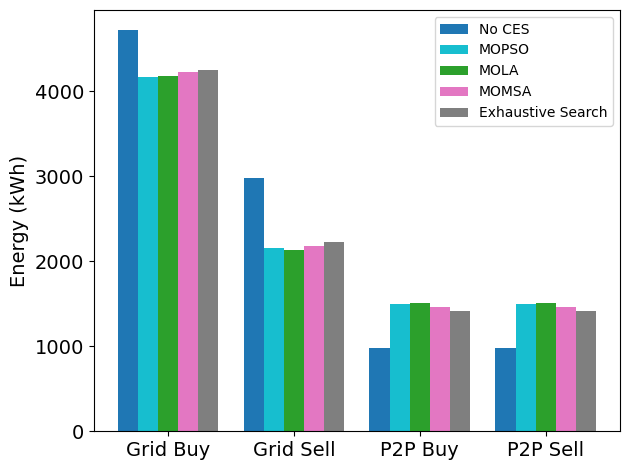

In [4]:
sol_folder = ['no CES', 'MOPSO', 'MOLA', 'MOMSA', r'Benchmark\opt_result']

gbuy_total, gsell_total, pbuy_total, psell_total = [], [], [], []
gbuy_total_time, gsell_total_time, pbuy_total_time, psell_total_time = {}, {}, {}, {}

# P2P trading amount breakdown
for i in range(len(sol_folder)):
    gbuy_loc        = fr"{sol_folder[i]}\Grid_buy.csv"
    gsell_loc       = fr"{sol_folder[i]}\Grid_sell.csv"
    pbuy_loc        = fr"{sol_folder[i]}\P2P_buy.csv"
    psell_loc       = fr"{sol_folder[i]}\P2P_sell.csv"

    gbuy_p2p        = pd.read_csv(gbuy_loc, header=None).to_numpy()[:,:-1]
    gsell_p2p       = pd.read_csv(gsell_loc, header=None).to_numpy()[:,:-1]
    pbuy_p2p        = pd.read_csv(pbuy_loc, header=None).to_numpy()[:,:-1]
    psell_p2p       = pd.read_csv(psell_loc, header=None).to_numpy()[:,:-1]

    # Calculate total amounts for each category
    gbuy_total.append(np.sum(gbuy_p2p))
    gsell_total.append(np.sum(gsell_p2p))
    pbuy_total.append(np.sum(pbuy_p2p))
    psell_total.append(np.sum(psell_p2p))

    gbuy_total_time[i], gsell_total_time[i], pbuy_total_time[i], psell_total_time[i] = \
        np.sum(gbuy_p2p, axis=1), np.sum(gsell_p2p, axis=1), np.sum(pbuy_p2p, axis=1), np.sum(psell_p2p, axis=1)

# Set up the bar chart
fig, ax = plt.subplots()

# Set position of bar on X axis
x = np.arange(4)
width = 0.35

# Create bars
# Dynamic width based on number of methods to avoid overlap
n = len(sol_folder)
width = 0.8 / n
offsets = (np.arange(n) - (n - 1) / 2) * width

labels = ['No CES', 'MOPSO', 'MOLA', 'MOMSA', 'Exhaustive Search']
colors = ["#1f77b4", "#17becf", "#2ca02c", "#e377c2", "#7f7f7f"]

rects = []
for i in range(n):
    vals = [gbuy_total[i], gsell_total[i], pbuy_total[i], psell_total[i]]
    rect = ax.bar(x + offsets[i], vals, width, label=labels[i] if i < len(labels) else sol_folder[i],
                  color=colors[i] if i < len(colors) else None)
    rects.append(rect)

# Customize the plot
ax.set_ylabel('Energy (kWh)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Grid Buy', 'Grid Sell', 'P2P Buy', 'P2P Sell'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(r'Benchmark\p2p_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot breakdown over time
# fig, ax = plt.subplots(figsize=(10, 6))
# time_hours = np.arange(1, 49) 

# # for i in range(len(sol_folder)):
# for i in range(len(sol_folder)):
#     # ax.plot(time_hours, pbuy_total_time[i], label=f'P2P Buy - {labels[i]}')
#     # ax.plot(time_hours, psell_total_time[i], label=f'P2P Sell - {labels[i]}')
#     # ax.plot(time_hours, gbuy_total_time[i], label=f'Grid Buy - {labels[i]}', linestyle='--')
#     # ax.plot(time_hours, gsell_total_time[i], label=f'Grid Sell - {labels[i]}', linestyle='--')
#     ax.plot(time_hours, pbuy_total_time[i], label=f'P2P Traded - {labels[i]}')
#     # ax.plot(time_hours, psell_total_time[i], label=f'P2P Traded - {labels[i]}')
#     # ax.plot(time_hours, gbuy_total_time[i], label=f'Grid Buy - {labels[i]}', linestyle='--')
#     # ax.plot(time_hours, gsell_total_time[i], label=f'Grid Sell - {labels[i]}', linestyle='--')
# ax.set_xlabel('Time (hours)', fontsize=14)
# ax.set_ylabel('Energy (kWh)', fontsize=14)
# ax.tick_params(axis='y', labelsize=14)
# ax.set_title('P2P Trading Breakdown Over Time', fontsize=16)
# ax.legend(fontsize=10)
# plt.tight_layout()
# plt.savefig(r'Benchmark\p2p_time_breakdown.png', dpi=300, bbox_inches='tight')
# plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
C:\Users\PC\AppData\Local\Temp\ipykernel_54664\3818417975.py:68: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig("Benchmark\power_exchange_profile.svg")


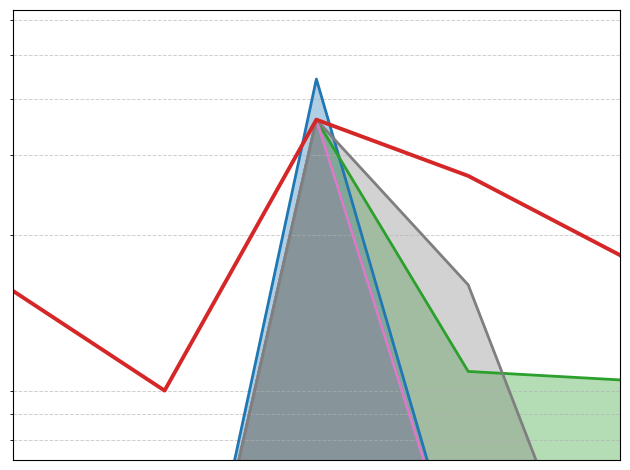

In [32]:
branch_power_loc = 'BranchPowerAll.xlsx'
branch_power = pd.read_excel(branch_power_loc, header=None).to_numpy()
category = branch_power[:, 0]
branch_power = branch_power[:, 1:]

category[0], category[4] = 'no CES', 'Exhaustive Search'

branch_idx = np.arange(1, branch_power.shape[1] + 1)
p_no_ces = branch_power[0, :]
p_mopso = branch_power[1, :]
p_mola = branch_power[2, :]
p_momsa = branch_power[3, :]
p_es = branch_power[4, :]
branch_limit = branch_power[5, :]

colors = {
    "no_ces":   "#1f77b4",  # blue
    "mopso":    "#17becf",  # cyan
    "mola":     "#2ca02c",  # green
    "momsa":    "#e377c2",  # magenta
    "es":       "#7f7f7f",  # grey
    "limit":    "#d62728"   # red
}

branch_idx   = np.asarray(branch_idx, dtype=float).ravel()
p_no_ces     = np.asarray(p_no_ces, dtype=float).ravel()
p_mopso      = np.asarray(p_mopso, dtype=float).ravel()
p_mola       = np.asarray(p_mola, dtype=float).ravel()
p_momsa      = np.asarray(p_momsa, dtype=float).ravel()
p_es         = np.asarray(p_es, dtype=float).ravel()
branch_limit = np.asarray(branch_limit, dtype=float).ravel()
plt.figure()

# Filled curves
plt.fill_between(branch_idx, p_no_ces, color=colors["no_ces"], alpha=0.35, label='no CES')
plt.plot(branch_idx, p_no_ces, color=colors["no_ces"], linewidth=2)

plt.fill_between(branch_idx, p_mopso, color=colors["mopso"], alpha=0.35, label='MOPSO')
plt.plot(branch_idx, p_mopso, color=colors["mopso"], linewidth=2)

plt.fill_between(branch_idx, p_mola, color=colors["mola"], alpha=0.35, label='MOLA')
plt.plot(branch_idx, p_mola, color=colors["mola"], linewidth=2)

plt.fill_between(branch_idx, p_momsa, color=colors["momsa"], alpha=0.35, label='MOMSA')
plt.plot(branch_idx, p_momsa, color=colors["momsa"], linewidth=2)

plt.fill_between(branch_idx, p_es, color=colors["es"], alpha=0.35, label='Exhaustive Search')
plt.plot(branch_idx, p_es, color=colors["es"], linewidth=2)

plt.plot(branch_idx, branch_limit, color=colors["limit"], linewidth=2.8, label='Branch Limit')

# ----------------------------
# Axis formatting
# ----------------------------
plt.yscale('log')
# plt.xlabel('Branch', fontsize=14)
# plt.ylabel('Log-scaled Power Flow (kW)', fontsize=14)
plt.xticks([])
plt.yticks([])
plt.xlim(left=16,right=20)
plt.ylim(bottom=10**1.8, top=10**2.8)
# plt.title('Power Exchange Profile ', fontsize=14)

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.6)
# plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("Benchmark\power_exchange_profile.svg")
plt.show()